# JobLens Vietnam — Mạng kỹ năng và cụm JD

Đồ thị mô tả kỹ năng cùng được đề cập. Embeddings dùng mô hình đa ngôn ngữ, UMAP 15 chiều trước KMeans/HDBSCAN. Các cụm là cấu trúc nội dung khám phá, không phải nhãn nghề đã kiểm định.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
from IPython.display import display, Image, Markdown

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "configs/pipeline.json").exists() and (p / "main.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Mở notebook trong thư mục project")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.utils import read_frame
from src.pipeline import load_config, run_pipeline
CONFIG = load_config(ROOT / "configs/pipeline.json")
if not (ROOT / "data/processed/jobs_cleaned.parquet").exists():
    run_pipeline("prepare")
jobs = read_frame(ROOT / "data/processed/jobs_cleaned.parquet")
print(f"{len(jobs):,} tin; {jobs.company_group.nunique():,} nhóm công ty")


14,034 tin; 5,868 nhóm công ty


## 1. Trích kỹ năng và multi-hot

Vocabulary EDA/cluster được học trên toàn bộ bộ dữ liệu mô tả. Vocabulary của mô hình lương được fit riêng trên train để tránh rò rỉ đánh giá.

In [2]:
from src.features.build_features import create_skill_matrix
matrix = create_skill_matrix(jobs, min_frequency=CONFIG["skill_min_frequency"])
print("Skill matrix:", matrix.shape)
display(matrix.head())

Skill matrix: (14034, 235)


,skill_.NET,skill_ARM,skill_ASP.NET Core,skill_AWS,skill_ActiveMQ,skill_Adobe XD,skill_Agile,skill_Airflow,skill_Android,skill_Angular,...,skill_WinForms,skill_Windows Server,skill_WordPress,skill_XGBoost,skill_Zabbix,skill_dbt,skill_gRPC,skill_iOS,skill_jQuery,skill_scikit-learn
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 2. Đồng xuất hiện và centrality

Chỉ giữ kỹ năng ≥50 tin và cặp ≥20 tin theo cấu hình. Cạnh có count, Jaccard, lift. Betweenness tính không trọng số; count không được coi là khoảng cách.

nodes          171.000000
edges         3437.000000
density          0.236464
components       2.000000
dtype: float64

,skill,job_count,degree,weighted_degree,degree_centrality,betweenness_centrality
76,JavaScript,2062,99,19667,0.582353,0.019715
57,Git,1684,125,19237,0.735294,0.050716
120,Python,1822,136,17659,0.800000,0.073160
97,MySQL,1548,119,17483,0.700000,0.031434
132,SQL,2037,133,17423,0.782353,0.066368
20,CSS,1729,89,16930,0.523529,0.011814
66,HTML,1748,89,16688,0.523529,0.011667
123,REST API,1378,102,16182,0.600000,0.020776
40,Docker,1128,122,15655,0.717647,0.040253
125,React,1325,88,14563,0.517647,0.009306


,.NET,ASP.NET Core,AWS,Agile,Airflow,Android,Angular,Ansible,Argo CD,Azure,Bash,BigQuery
.NET,0.0,100.0,101.0,114.0,0.0,66.0,220.0,0.0,0.0,106.0,0.0,0.0
ASP.NET Core,100.0,0.0,0.0,0.0,0.0,0.0,36.0,0.0,0.0,0.0,0.0,0.0
AWS,101.0,0.0,0.0,179.0,42.0,24.0,101.0,100.0,38.0,528.0,118.0,28.0
Agile,114.0,0.0,179.0,0.0,0.0,67.0,137.0,22.0,0.0,127.0,0.0,0.0
Airflow,0.0,0.0,42.0,0.0,0.0,0.0,0.0,0.0,0.0,36.0,0.0,30.0
Android,66.0,0.0,24.0,67.0,0.0,0.0,30.0,0.0,0.0,0.0,0.0,0.0
Angular,220.0,36.0,101.0,137.0,0.0,30.0,0.0,0.0,0.0,70.0,0.0,0.0
Ansible,0.0,0.0,100.0,22.0,0.0,0.0,0.0,0.0,38.0,65.0,72.0,0.0
Argo CD,0.0,0.0,38.0,0.0,0.0,0.0,0.0,38.0,0.0,22.0,36.0,0.0
Azure,106.0,0.0,528.0,127.0,36.0,0.0,70.0,65.0,22.0,0.0,76.0,28.0


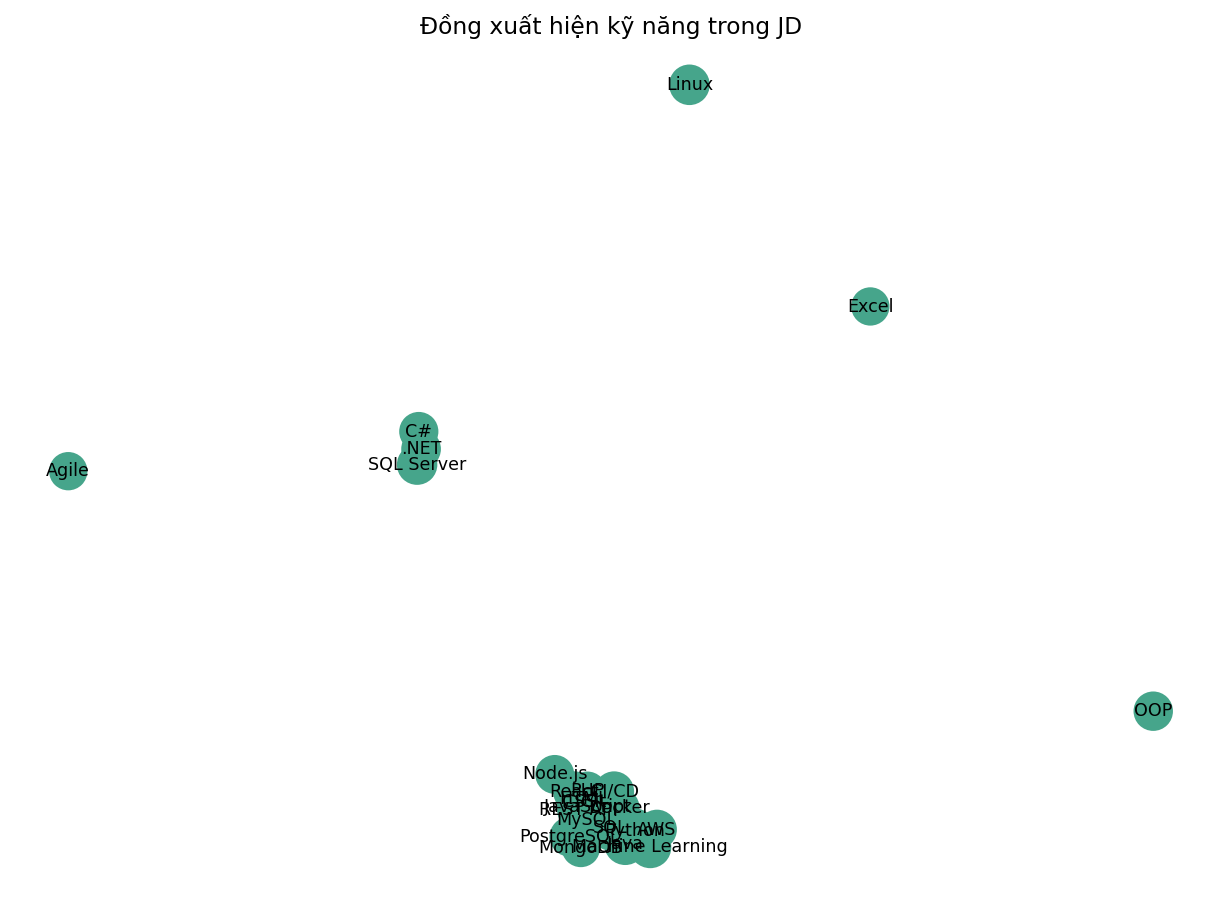

In [3]:
from src.models.cluster import build_skill_cooccurrence_graph, skill_graph_statistics
graph = build_skill_cooccurrence_graph(jobs.extracted_skills, **CONFIG["graph"])
centrality, topology = skill_graph_statistics(graph)
display(pd.Series(topology))
display(centrality.head(20))
import networkx as nx
display(nx.to_pandas_adjacency(graph, weight="weight").iloc[:12, :12])
display(Image(filename=str(ROOT / "reports/figures/skill_network.png")))

## 3. Sentence embeddings và UMAP

Lượt đầu tải mô hình từ Hugging Face, có thể mất vài phút trên CPU. Cache kiểm tra fingerprint nội dung và cấu hình. JD bị cắt theo max_seq_length; phần cuối của JD dài có thể không tham gia embedding.

In [4]:
RECOMPUTE = False
from src.pipeline import features, cluster
if RECOMPUTE:
    values = features(jobs, CONFIG)
    cluster(jobs, CONFIG, values)
path = ROOT / "reports/clustering_metrics.json"
if not path.exists():
    raise FileNotFoundError("Chạy main.py --stage all hoặc bật RECOMPUTE")
clustering = json.loads(path.read_text(encoding="utf-8"))
if not clustering["semantic"]:
    raise RuntimeError("Lượt trước bỏ embeddings; chạy main.py --stage cluster")
display(pd.DataFrame(clustering["semantic"].values()))

,method,clusters,noise_rows,silhouette_reduced_space,rows
0,kmeans,8,0,0.481774,14034
1,hdbscan,44,5060,0.528416,14034


## 4. Đọc và mô tả các cụm

Silhouette tính trên không gian UMAP, không so trực tiếp với chất lượng nhãn nghề. Biểu đồ dùng hai tọa độ đầu trong 15 chiều, các điểm chồng nhau có thể vẫn khác trong chiều còn lại. HDBSCAN có nhãn -1 cho noise.

,cluster,rows,top_skills,top_roles,median_salary_vnd
0,0,3310,"JavaScript, CSS, HTML, Git, MySQL, React, REST...","Software Engineer: 2765, Other: 509, Data Engi...",17500000.0
1,1,3348,"Firewall, Linux, CCNA, Cisco, DNS, Windows Ser...","Other: 3229, Software Engineer: 102, Data Anal...",11500000.0
2,2,887,"C++, Excel, C#, Python, STM32, TCP/IP, Machine...","Other: 781, Software Engineer: 100, Data Engin...",12500000.0
3,3,3462,"Python, SQL, Machine Learning, AWS, Docker, CI...","Other: 1783, Software Engineer: 729, Data Anal...",17500000.0
4,4,547,"Android, iOS, Git, OOP, Kotlin, REST API, Swif...","Software Engineer: 470, Other: 75, Data Analys...",17500000.0
5,5,2430,"Excel, SQL, JavaScript, HTML, WordPress, CSS, ...","Other: 2255, Software Engineer: 105, Data Anal...",14000000.0
6,6,26,"Firewall, SQL Server, DNS, DHCP, Cisco",Other: 26,10000000.0
7,7,24,NaN,Other: 24,17500000.0


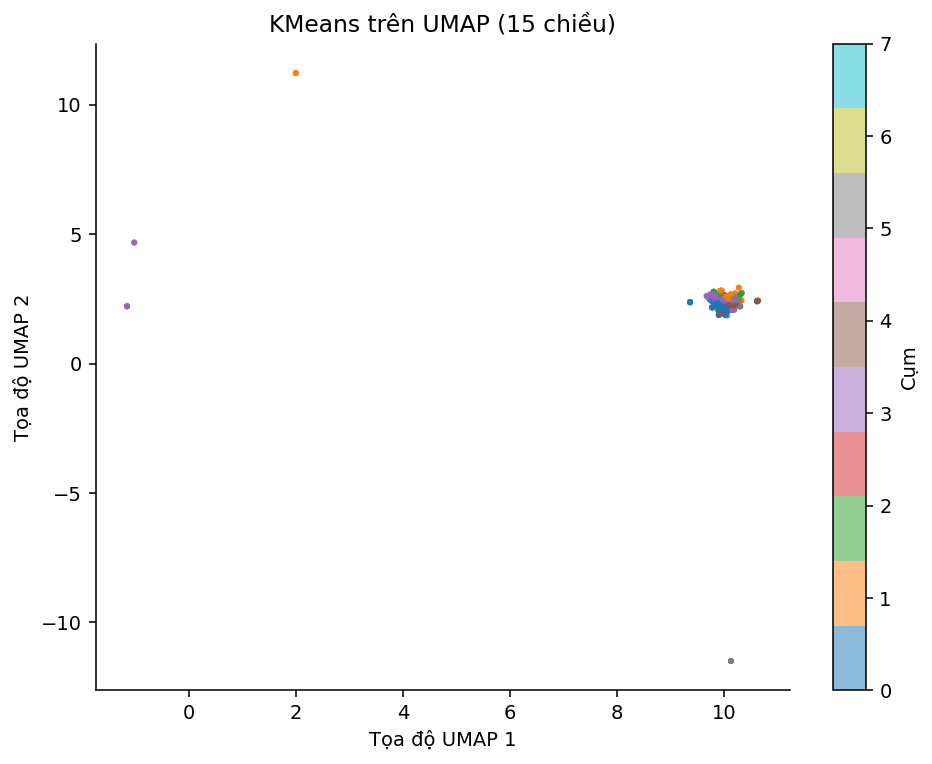

role_standard,AI/ML Engineer,Data Analyst,Data Engineer,Data Scientist,Other,Software Engineer
kmeans_cluster,,,,,,
0,4,9,23,0,509,2765
1,5,10,2,0,3229,102
2,2,1,3,0,781,100
3,246,464,143,97,1783,729
4,0,2,0,0,75,470
5,2,64,4,0,2255,105
6,0,0,0,0,26,0
7,0,0,0,0,24,0


hdbscan_cluster
-1     5060
 21    2467
 4      598
 16     584
 23     465
 17     432
 39     402
 8      401
 42     355
 10     255
 14     246
 41     242
 7      168
 36     166
 43     166
Name: rows, dtype: int64

In [5]:
assignments = pd.read_csv(ROOT / "reports/cluster_assignments.csv")
summary = pd.read_csv(ROOT / "reports/cluster_summary.csv")
display(summary)
display(Image(filename=str(ROOT / "reports/figures/clusters.png")))
display(pd.crosstab(assignments.kmeans_cluster, assignments.role_standard))
display(assignments.hdbscan_cluster.value_counts().rename("rows").head(15))

## 5. Xem ví dụ trong cụm

Sửa SELECTED_CLUSTER để đối chiếu title, mô tả và kỹ năng. Cụm cần đọc thủ công trước khi đặt tên; không đặt tên chỉ từ điểm silhouette.

In [6]:
SELECTED_CLUSTER = 0
ids = assignments.loc[assignments.kmeans_cluster.eq(SELECTED_CLUSTER), "id"].head(12)
display(jobs.loc[jobs.id.isin(ids), ["title_clean", "role_standard", "extracted_skills", "salary_mean"]])

,title_clean,role_standard,extracted_skills,salary_mean
3,Lâp Trình Viên/ Software Engineer/ IT,Software Engineer,"[Integration Testing, JavaScript, OOP, Python,...",12500000.0
4,Software Engineer (Fintech),Software Engineer,"[Angular, Java, JavaScript, Node.js, Python, R...",17000000.0
5,Software Engineer (Fullstack Java/Reactjs),Software Engineer,"[AWS, Angular, Azure, CSS, Docker, GCP, GitLab...",30600000.0
8,Java Backend Developer (Banking),Software Engineer,"[GraphQL, Java, Microservices, MongoDB, REST A...",NaN
9,"Middle Frontend (Thu Nhập 18-25tr/Tháng, Nguyễ...",Software Engineer,"[CI/CD, CSS, Figma, Git, GraphQL, HTML, JavaSc...",21500000.0
10,Senior Back-End Engineer (Java + ReactJS),Software Engineer,"[CI/CD, Docker, Java, Kafka, Kubernetes, Micro...",NaN
11,Backend/ Front-end Developer (Onsite Bank),Software Engineer,"[AWS, Angular, Java, Postman, React, Vue.js]",35000000.0
12,MIDDLE JAVA DEVELOPER,Software Engineer,"[Java, JavaScript, React, Spring Boot, Vue.js]",25500000.0
14,Nhân Viên Lập Trình (Part-Time),Software Engineer,"[.NET, CSS, GitHub, HTML, JavaScript, Machine ...",NaN
16,PHP DEVELOPER (Laravel),Software Engineer,"[Git, Laravel, MySQL, OAuth, OOP, PHP, REST AP...",25000000.0
